<a href="https://colab.research.google.com/github/Jingxian12/student-depression-prediction/blob/main/StudentDepression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <div align =center > **TITLE : STUDENT DEPRESSION PREDICTION**</div>

The objective of this application is to predict whether a student may be at risk of depression based on various academic, lifestyle, and personal factors. The model prioritizes recall to reduce the likelihood of missing students who may be experiencing depression, as undetected cases could negatively impact their well-being and quality of life.

**NOTES**
-  It is designed as an `early warning tool`, not a diagnosis, and users who show risk indicators should consider seeking support from counselors, mental health professionals, or trusted individuals.

- The dataset is likely `India-centric` based on the feature values, although this is not officially specified by the dataset author.

# **A) DATA INSPECTION**

### - Import Necessary Libraries

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import sklearn
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
import time
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

### - Upload Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Datasets
df = pd.read_csv("/content/drive/MyDrive/dataset/student_depression_dataset.csv")

In [ ]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


### - Rename Attributes Names

Before we start inspection, we renamed all the column names first

In [ ]:
df.columns = [
    'id',
    'gender',
    'age',
    'city',
    'profession',
    'academic_pressure',
    'work_pressure',
    'cgpa',
    'study_satisfaction',
    'job_satisfaction',
    'sleep_duration',
    'dietary_habits',
    'degree',
    'suicidal_thoughts',
    'work_study_hours',
    'financial_stress',
    'family_history_mental_illness',
    'depression'
]

- The column names were renamed to follow standard coding conventions, using lowercase letters and underscores as separators.
- This helps ensure consistency, makes the dataset easier to read, and prevents errors when working with code or data analysis tools

In [ ]:
df

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


### - Check Data Shape

In [ ]:
df.shape

(27901, 18)

- From here, we know that the dataset consists of 27901 rows and 18 columns(attributes)

### - Get Dataset info (Missing Values, data type)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             27901 non-null  int64  
 1   gender                         27901 non-null  object 
 2   age                            27901 non-null  float64
 3   city                           27901 non-null  object 
 4   profession                     27901 non-null  object 
 5   academic_pressure              27901 non-null  float64
 6   work_pressure                  27901 non-null  float64
 7   cgpa                           27901 non-null  float64
 8   study_satisfaction             27901 non-null  float64
 9   job_satisfaction               27901 non-null  float64
 10  sleep_duration                 27901 non-null  object 
 11  dietary_habits                 27901 non-null  object 
 12  degree                         27901 non-null 

- We  can see that this dataset contain 3 missing values for columns"Financial Stress". (But still have possible hidden missing values such as empty srting [""], ["Unknown"], ["N/A"] in other features)

### - Check Duplicate Rows

Note: There may be the same student records in the dataset. We check the duplicate rows. If the values are all the same, it indicates the existence of duplicates and will show at output.

In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


- We can know that we dont have any duplicate rows in this dataset.

### - Check Proportion of target variable

In [ ]:
# When normalize = True, return proportions instead of raw counts(Formula : count of each value ÷ total number of rows)
df["depression"].value_counts(normalize=True) *100

,proportion
depression,
1,58.549873
0,41.450127


- We can see that the class is slightly imbalanced, but we just use for analysis first

# **B) EXPLORATORY DATA ANALYSIS (EDA)**

Exploratory Data Analysis (EDA) is the initial stage of data analysis where the main goal is to understand the structure, quality, and patterns within a dataset before building any machine learning model.

In [ ]:
df = df.drop(columns=['id'])

We delete column "id" before EDA. Because it’s just a unique identifier
and has no predictive meaning. It can even make noise

## **Univariate EDA**

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

### (1) Numerical Features

In [ ]:
df[numerical_features].head()

,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work_study_hours,financial_stress,depression
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,1
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,1
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0


#### **Data Visualization**

#### i) Histogram

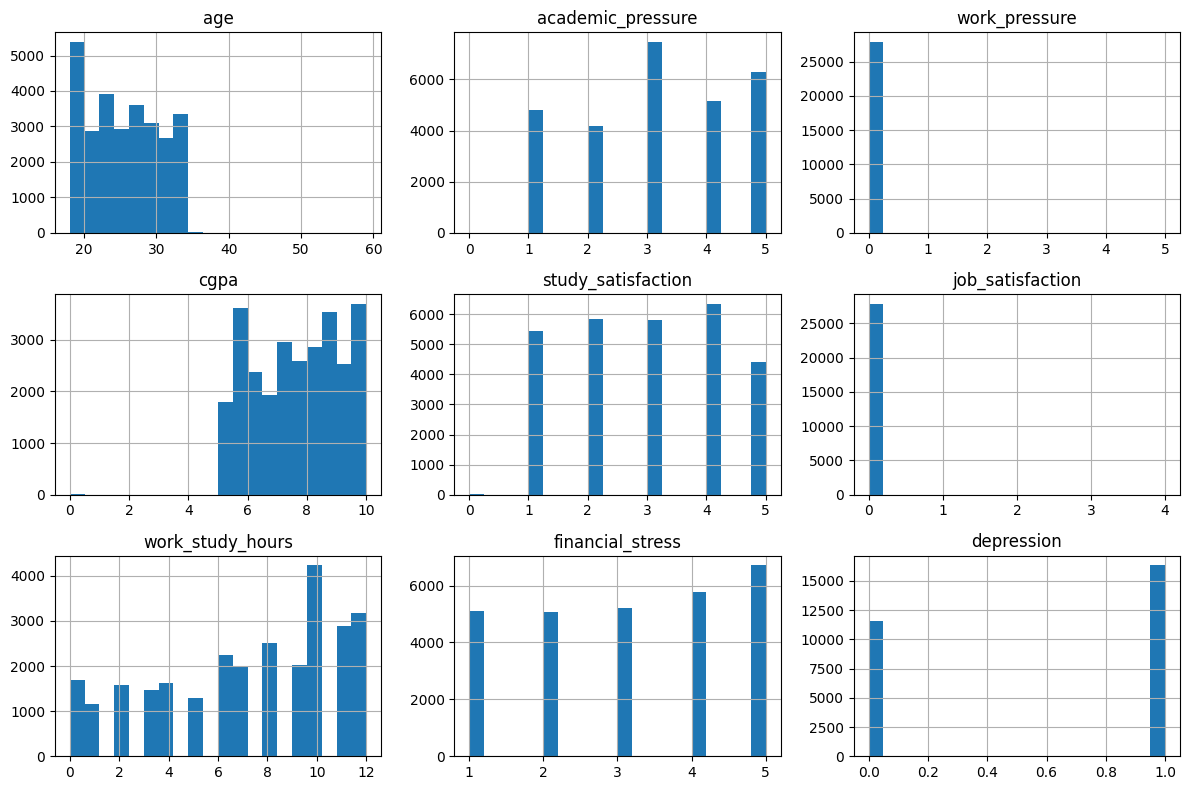

In [ ]:
df.hist(figsize=(12,8), bins=20) # .
plt.tight_layout()
plt.show()

#### ii) Boxplot

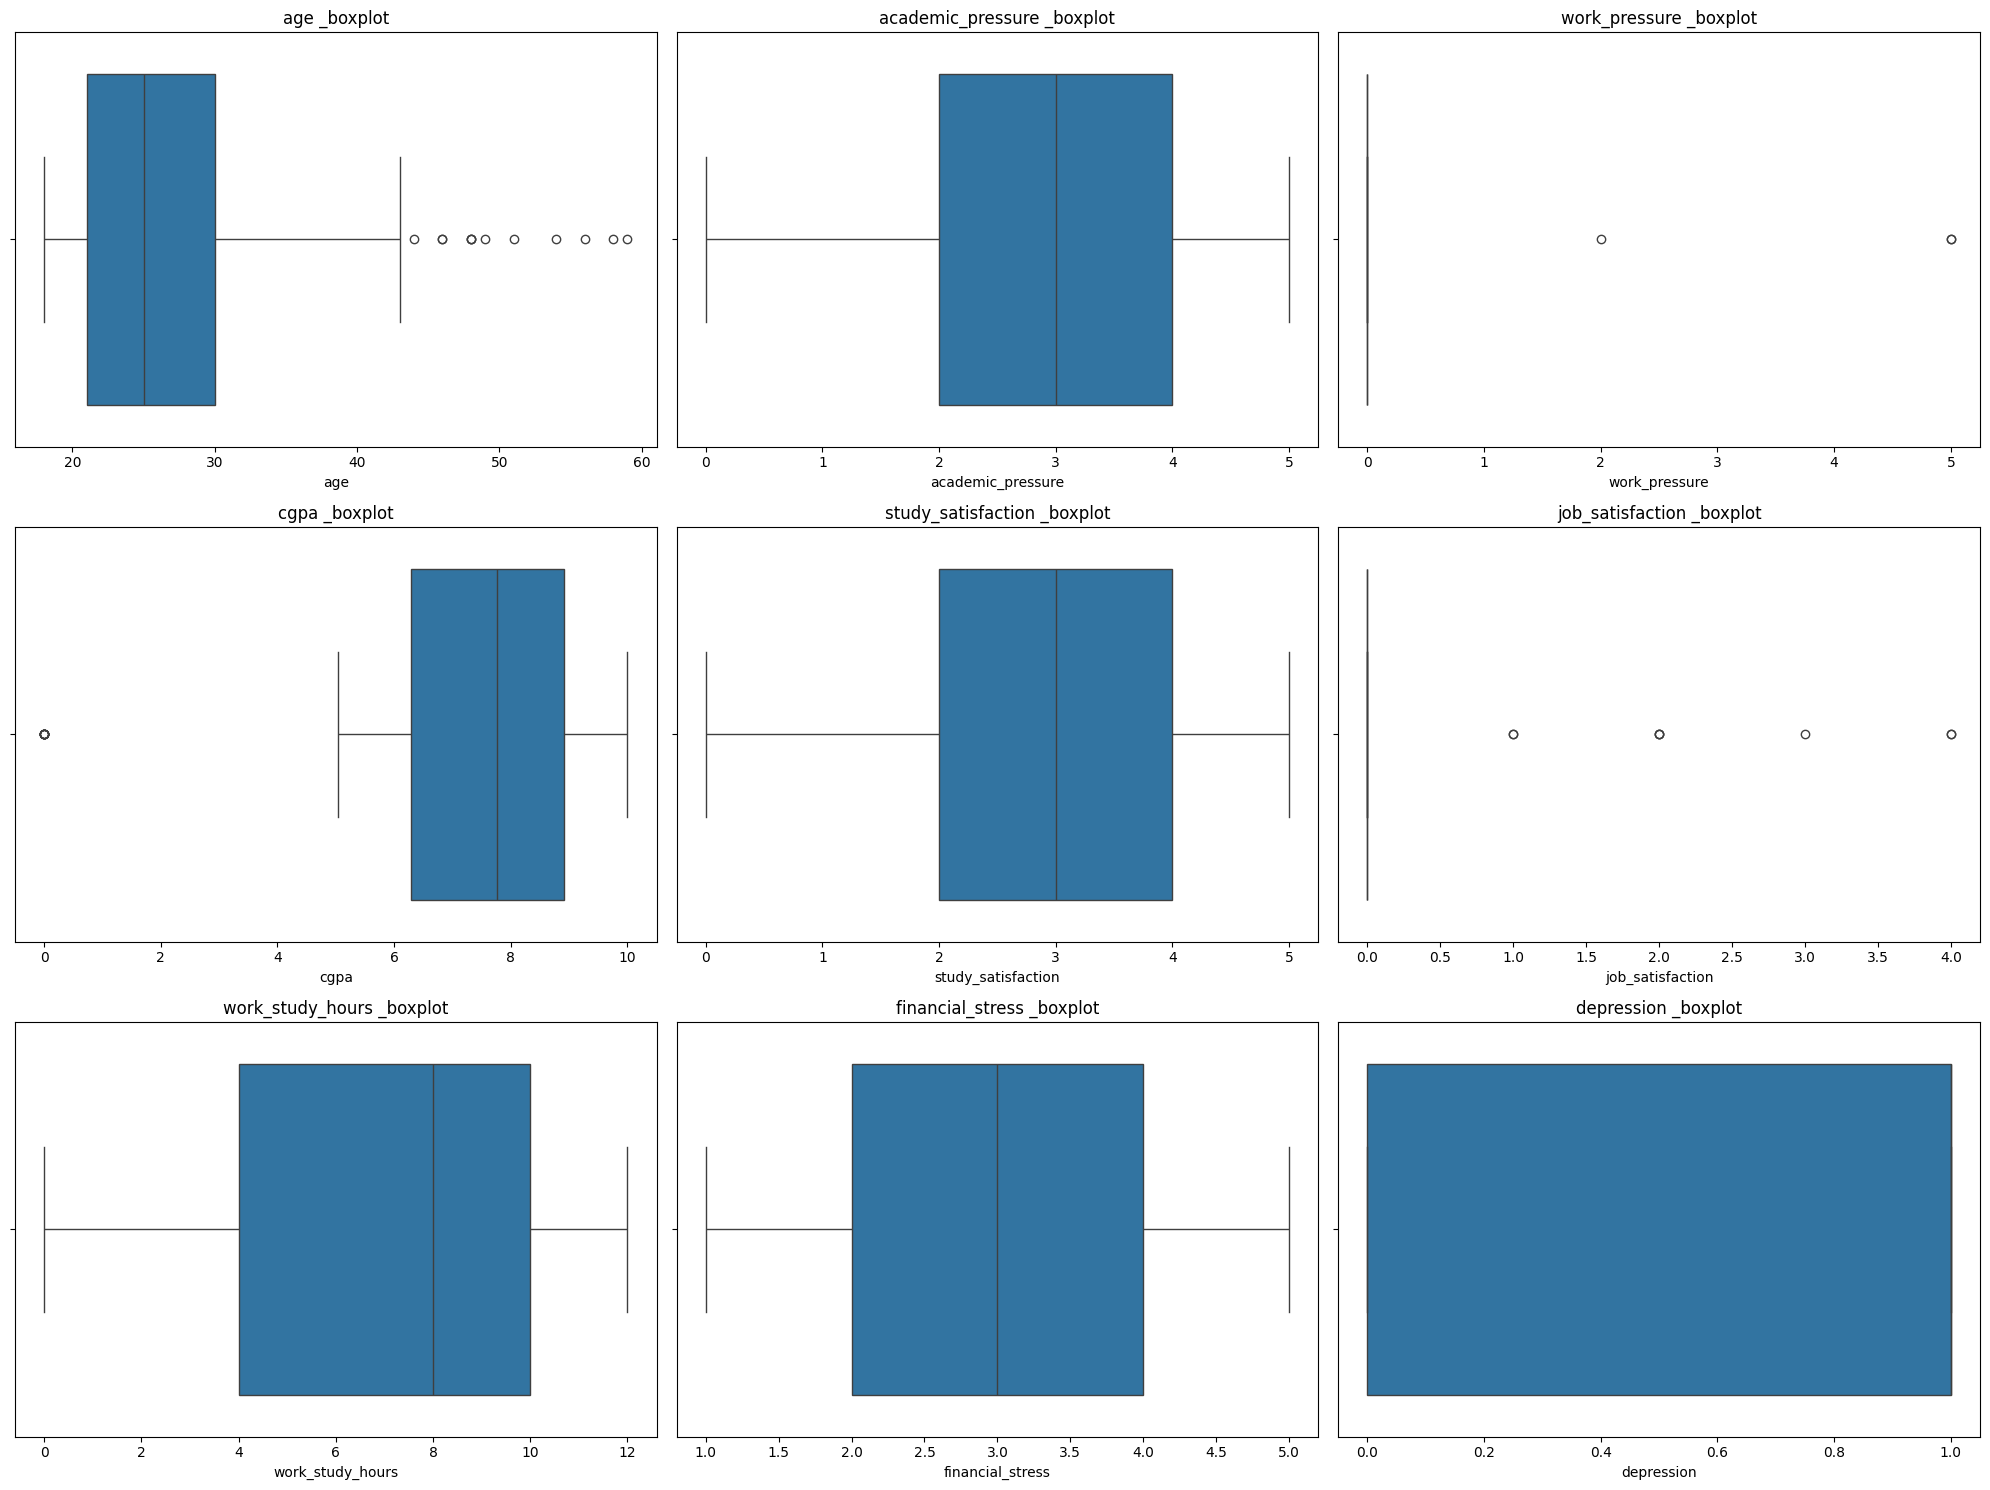

In [ ]:
cols = numerical_features
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} _boxplot")

plt.tight_layout()
plt.show()

Column "age" , "work_pressure", " cgpa", "job_satisfaction"  have outliers (circles). We need take attention of these features

#### iii) Correlation Heatmap

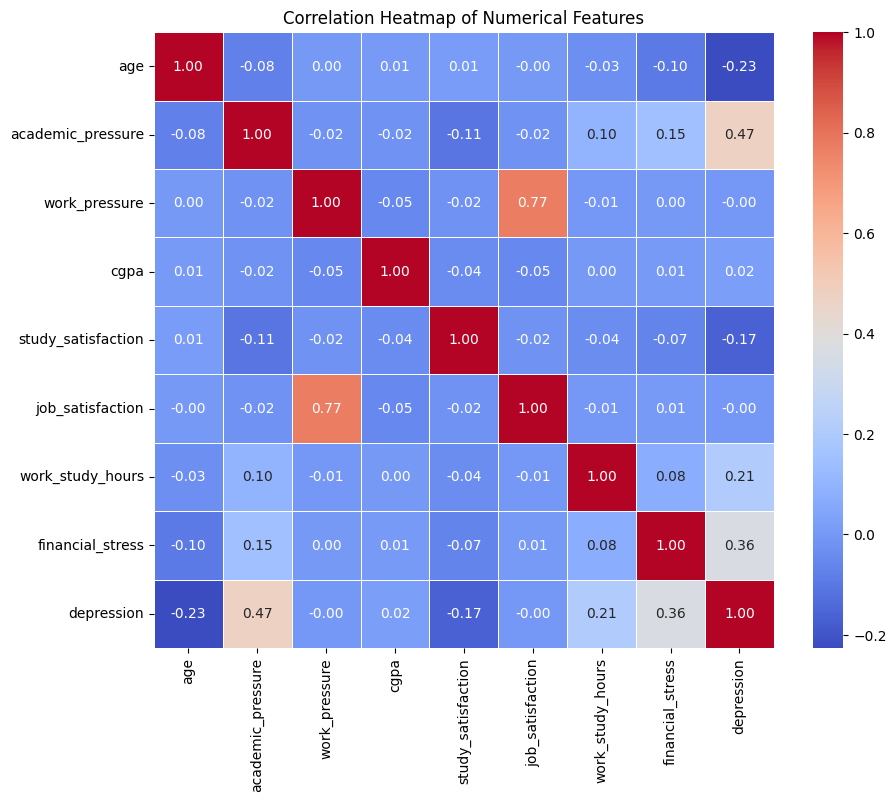

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()

# Set up the plot size
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) #annot = show corr values inside square

# Add title and show the plot
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Most features are not strongly correlated → this is good for:

- linear regression
- logistic regression
- SVM

### (2) Categorical Features

In [ ]:
df[categorical_features].head()

,gender,city,profession,sleep_duration,dietary_habits,degree,suicidal_thoughts,family_history_mental_illness
0,Male,Visakhapatnam,Student,5-6 hours,Healthy,B.Pharm,Yes,No
1,Female,Bangalore,Student,5-6 hours,Moderate,BSc,No,Yes
2,Male,Srinagar,Student,Less than 5 hours,Healthy,BA,No,Yes
3,Female,Varanasi,Student,7-8 hours,Moderate,BCA,Yes,Yes
4,Female,Jaipur,Student,5-6 hours,Moderate,M.Tech,Yes,No


#### i) Count Plot


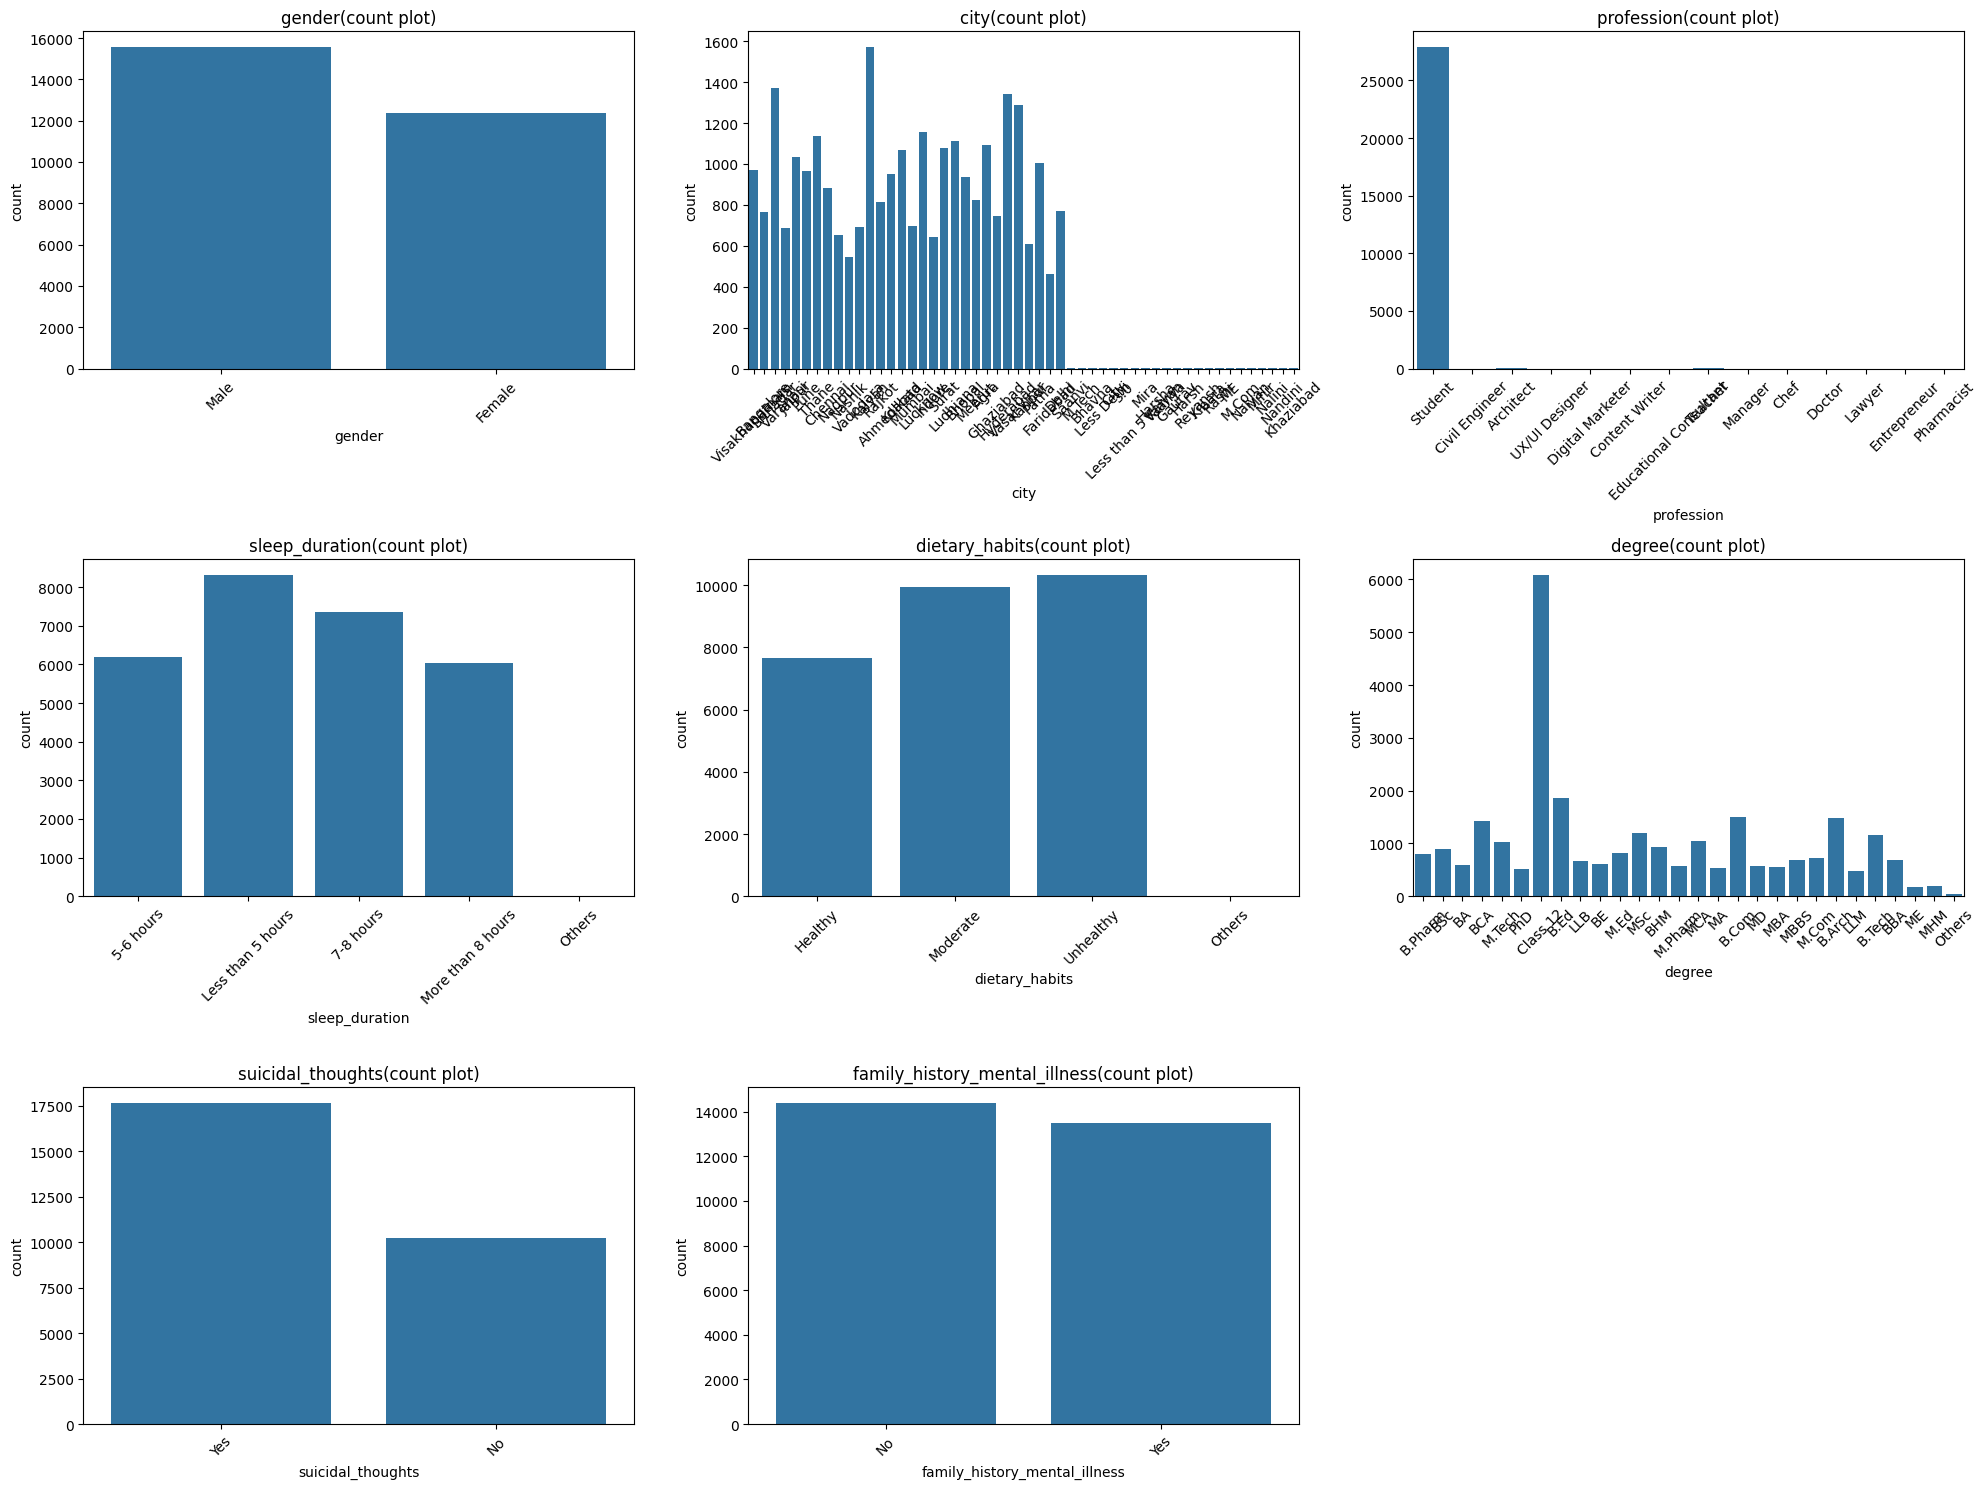

In [ ]:
cols = df.select_dtypes(include=['object']).columns

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(f"{col}(count plot)")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

 **FROM Graph**
 - From feature **`profession`**, we notice that this dataset is not purely students.Since our purpose is to predict student's depression, so it may possible make data inconsistency or mixed population.We Just remove the rows that not related to students.

 - Since the feature **`city`** count plot have many values, so we choose the most 10 values to see the frequency of feature.

 - **`degree`** feature have one value that is most values in graph.

Top 10 City

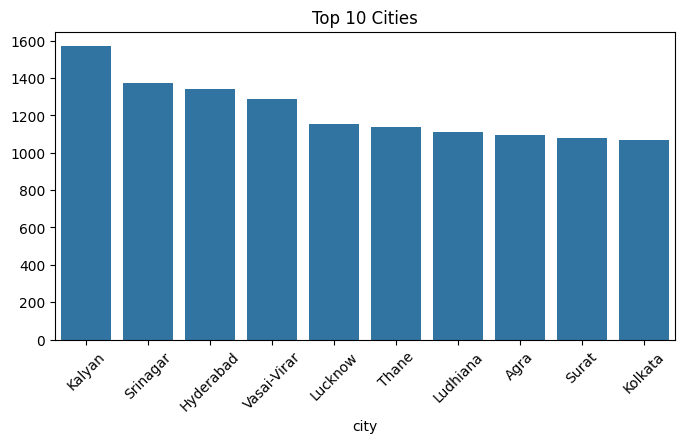

In [ ]:
plt.figure(figsize=(8,4))

top_cities = df['city'].value_counts().nlargest(10)

sns.barplot(x=top_cities.index, y=top_cities.values)
plt.xticks(rotation=45)
plt.title("Top 10 Cities")
plt.show()

Top 10 Degree


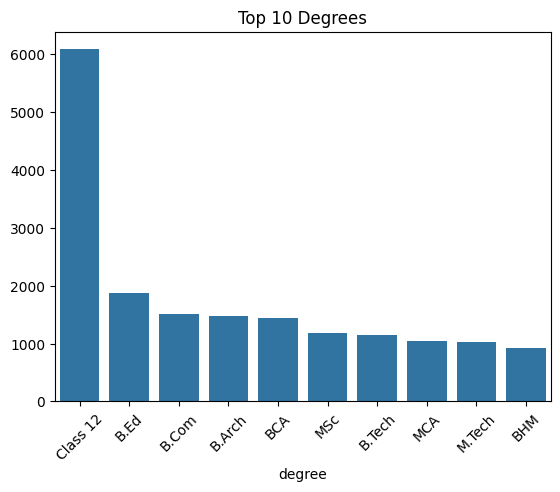

In [ ]:
top_degree = df['degree'].value_counts().nlargest(10)

sns.barplot(x=top_degree.index, y=top_degree.values)
plt.xticks(rotation=45)
plt.title("Top 10 Degrees")
plt.show()

#### ii) **value_counts**

In [ ]:
for i, col in enumerate(categorical_features, 1):
    print(f"{i}. Feature: {col}")
    print(df[col].value_counts())
    print("-"*50)

1. Feature: gender
gender
Male      15547
Female    12354
Name: count, dtype: int64
--------------------------------------------------
2. Feature: city
city
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna

**NOTE**
- **`profession`** feature have involve other occupation such as Manager, Teacher, Doctor and so on. Since our purpose is to predict student depression, so we show keep the data that only related to students.

In [ ]:
df = df[df["profession"] == "Student"]

In [ ]:
df["profession"].value_counts()

,count
profession,
Student,27870


## **Target-Based EDA**

### (1) Numerical Features

In [ ]:
df[numerical_features].head()

,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work_study_hours,financial_stress,depression
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,1
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,1
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0


In [ ]:
df[numerical_features].describe().round(3)

,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work_study_hours,financial_stress,depression
count,27870.000,27870.000,27870.000,27870.000,27870.000,27870.000,27870.000,27867.000,27870.000
mean,25.821,3.141,0.000,7.656,2.944,0.001,7.158,3.140,0.585
std,4.907,1.382,0.044,1.471,1.361,0.044,3.707,1.437,0.493
min,18.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
25%,21.000,2.000,0.000,6.290,2.000,0.000,4.000,2.000,0.000
50%,25.000,3.000,0.000,7.770,3.000,0.000,8.000,3.000,1.000
75%,30.000,4.000,0.000,8.920,4.000,0.000,10.000,4.000,1.000
max,59.000,5.000,5.000,10.000,5.000,4.000,12.000,5.000,1.000


From here, we can notice that the **`age`**,**`work_pressure`** and **`job_satisfaction`** have more suspicious

- **`Age`** feature have big distance between min and max (from 18 to 59), so we can check the value counts based on depression to get more info.

- Mean and std for features **`work_pressure`** and **`job_satisfaction`** have near-zero variance. They might not be useful predictors. Let's check with value counts and visualization

In [ ]:
df.groupby("depression")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
depression,,,,,,,,
0,11562.0,27.142363,4.943988,18.0,23.0,28.0,31.0,59.0
1,16308.0,24.884413,4.658268,18.0,21.0,24.0,28.0,48.0


The age distributions between the two groups are different.So there is a relationship between age and depression.

- Non-depressed median = 28, Depressed median = 24

- That’s a meaningful shift.

#### - Work Pressure, Job Satisfaction

In [ ]:
for col in ["work_pressure", "job_satisfaction"]:
  print("[", col, "]")
  print(df.groupby("depression")[col].describe())
  print("\n")

[ work_pressure ]
              count      mean       std  min  25%  50%  75%  max
depression                                                      
0           11562.0  0.000605  0.050081  0.0  0.0  0.0  0.0  5.0
1           16308.0  0.000307  0.039153  0.0  0.0  0.0  0.0  5.0


[ job_satisfaction ]
              count      mean       std  min  25%  50%  75%  max
depression                                                      
0           11562.0  0.000865  0.050933  0.0  0.0  0.0  0.0  4.0
1           16308.0  0.000552  0.039151  0.0  0.0  0.0  0.0  4.0




In [ ]:
for col in ["work_pressure", "job_satisfaction"]:
    print(df[col].value_counts(normalize=True))

work_pressure
0.0    0.999892
5.0    0.000072
2.0    0.000036
Name: proportion, dtype: float64
job_satisfaction
0.0    0.999713
2.0    0.000108
4.0    0.000072
1.0    0.000072
3.0    0.000036
Name: proportion, dtype: float64


Most of the values are "0.0",means that  not informative

99% of values are the same:

- the feature cannot separate classes well

#### - Feature vs Target

i) Boxplot

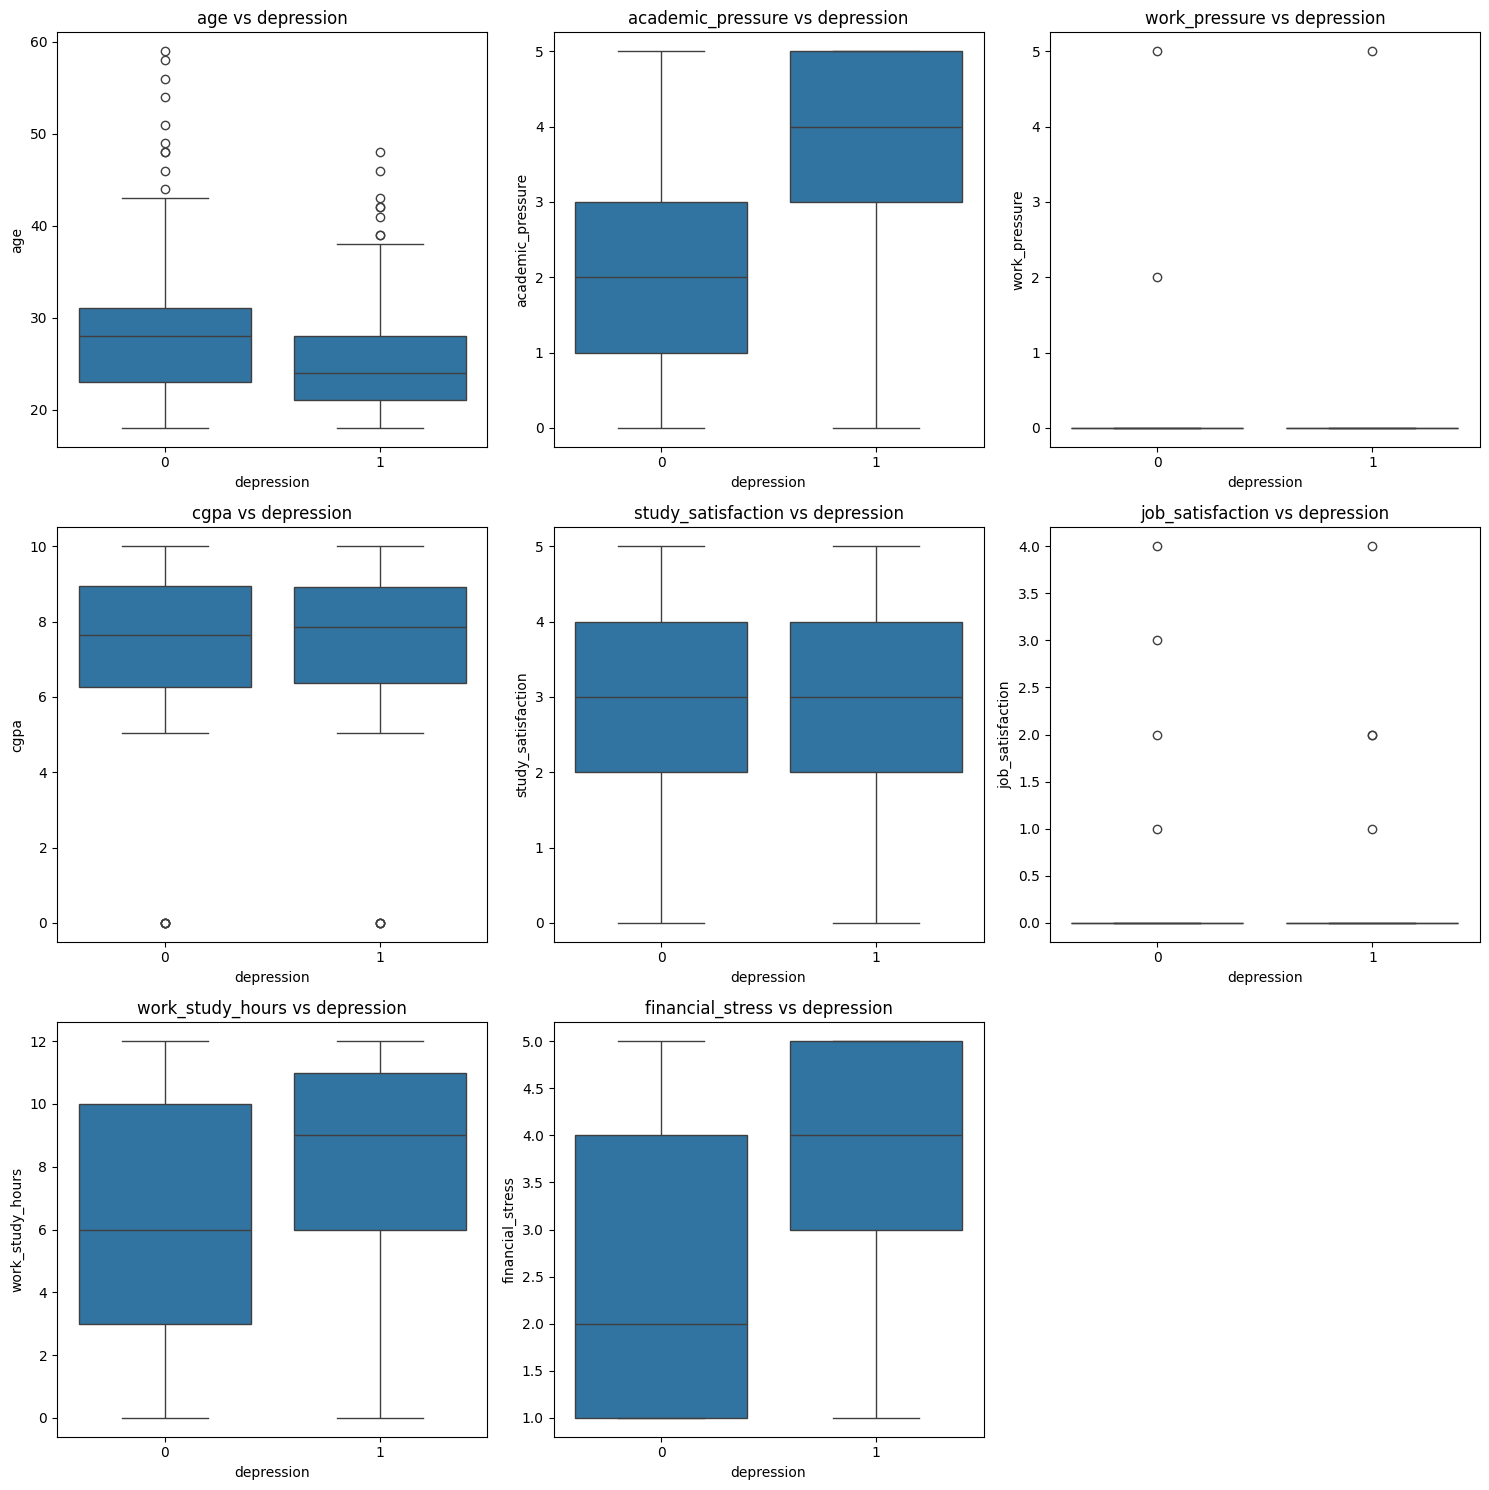

In [ ]:
target = 'depression'

features = [col for col in numerical_features if col != target]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

We can see that the box (IQR), median for **`work_preessure`** and  **`job_satisfaction`** is almost group at 0, so we check at correlation heatmap


***Feature Importance (The "Gap" Insight)***


> "If a feature displays a significant difference in its distribution across target classes, it indicates that the model can effectively use that variable to separate and distinguish between the groups."


**Significant Predictor:** If the boxes (the Interquartile Ranges) do not overlap
vertically, it tells you the feature is a high-impact variable for your model.

**Irrelevant Feature:** If the boxes are at the same horizontal level and the medians align, the feature is likely noise

ii) KDE Plot

/tmp/ipykernel_5463/2499485034.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue='depression', fill=True, ax=axes[i])


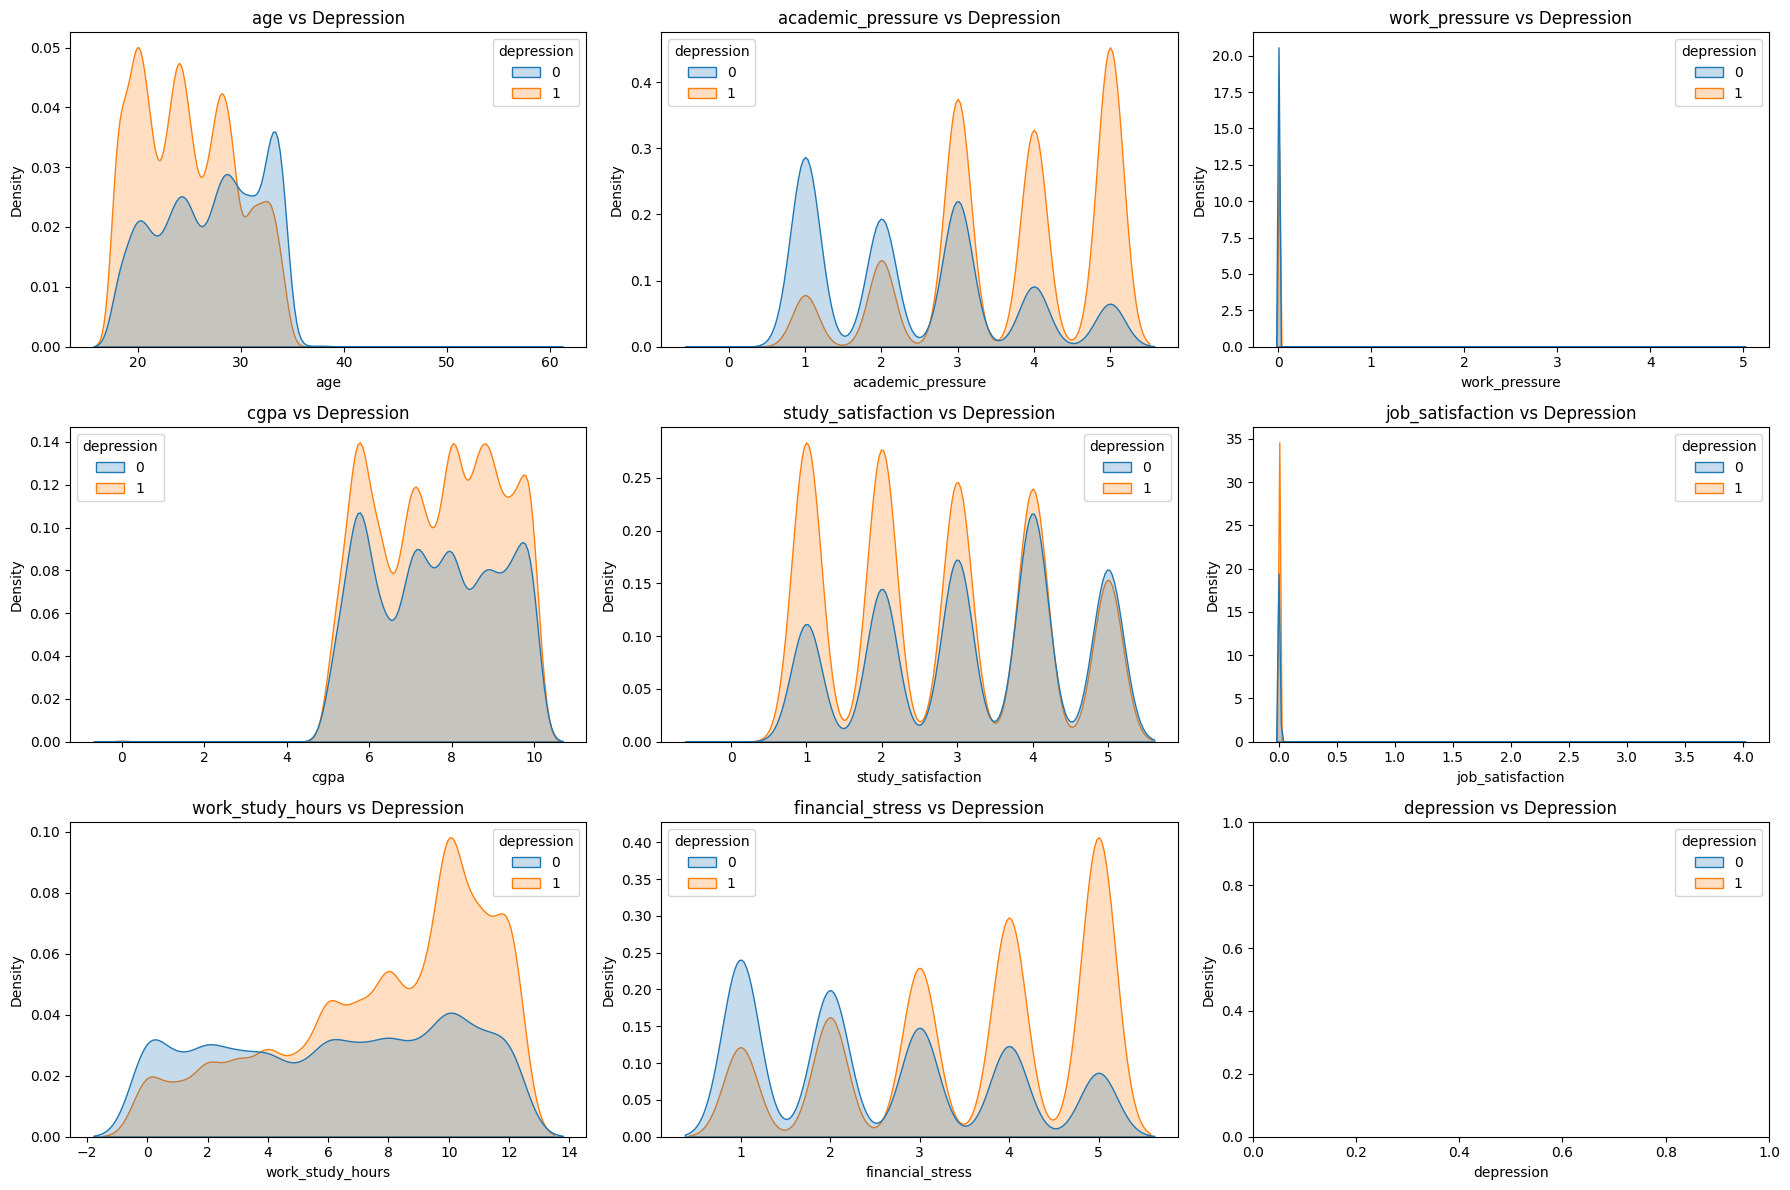

In [ ]:
cols = numerical_features
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, hue='depression', fill=True, ax=axes[i])
    axes[i].set_title(f"{col} vs Depression")

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

iii) Correlation Heatmap

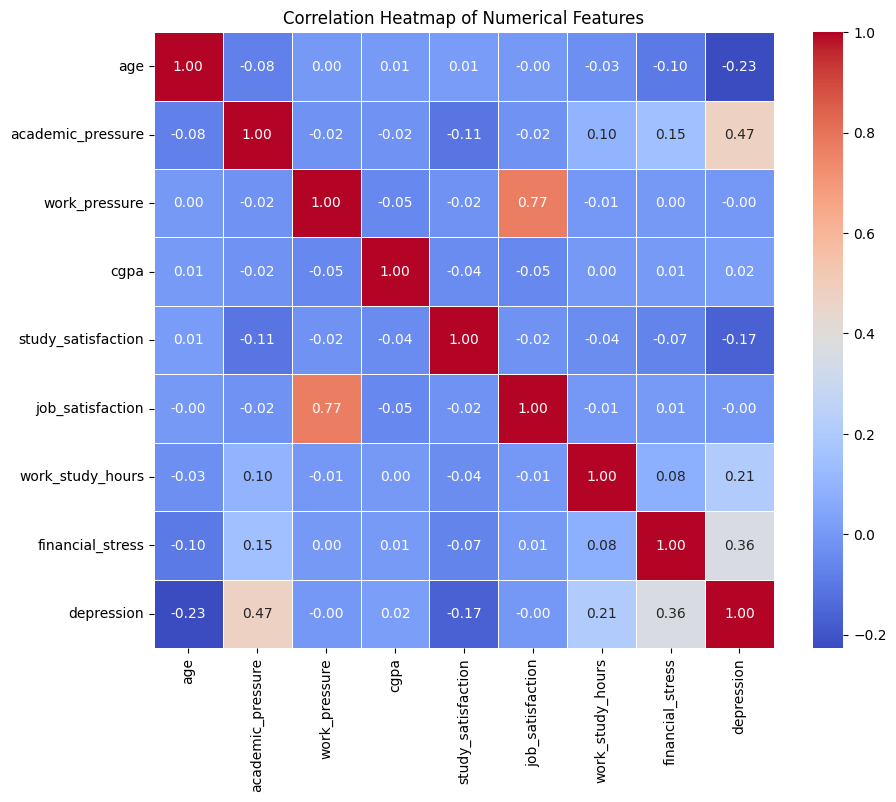

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()

# Set up the plot size
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) #annot = show corr values inside square

# Add title and show the plot
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Since some of the attributes(**`work pressure`** and **`job satisfaction`**) are not so related to target variable(**`Depression`**), so can remove it to reduce noice

iv) Proportional Stacked Bar Chart /  Count Plot

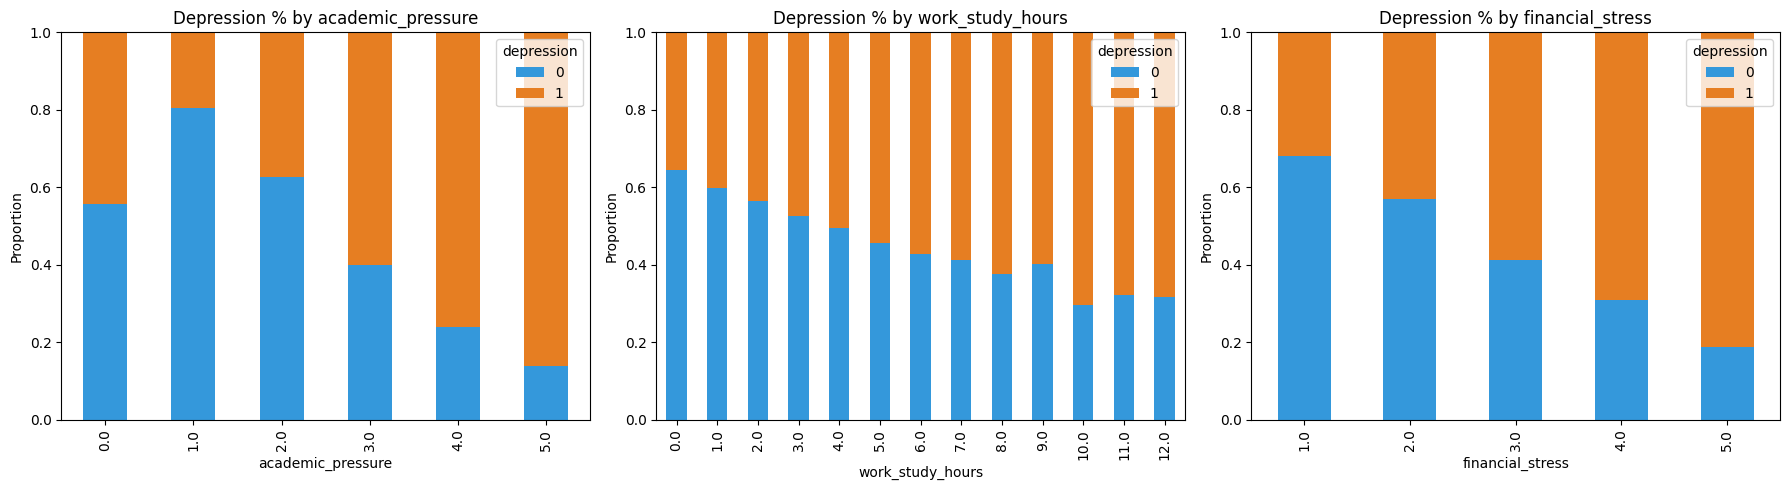

In [ ]:
# List the features you want to analyze
features = ['academic_pressure', 'work_study_hours', "financial_stress"]

# Create a layout with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    # Calculate proportions (normalized)
    props = df.groupby(col)['depression'].value_counts(normalize=True).unstack()

    # Plot on the specific subplot (axes[i])
    props.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e67e22'])

    axes[i].set_title(f'Depression % by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].set_ylim(0, 1) # Keep scale consistent 0 to 100%

plt.tight_layout()
plt.show()

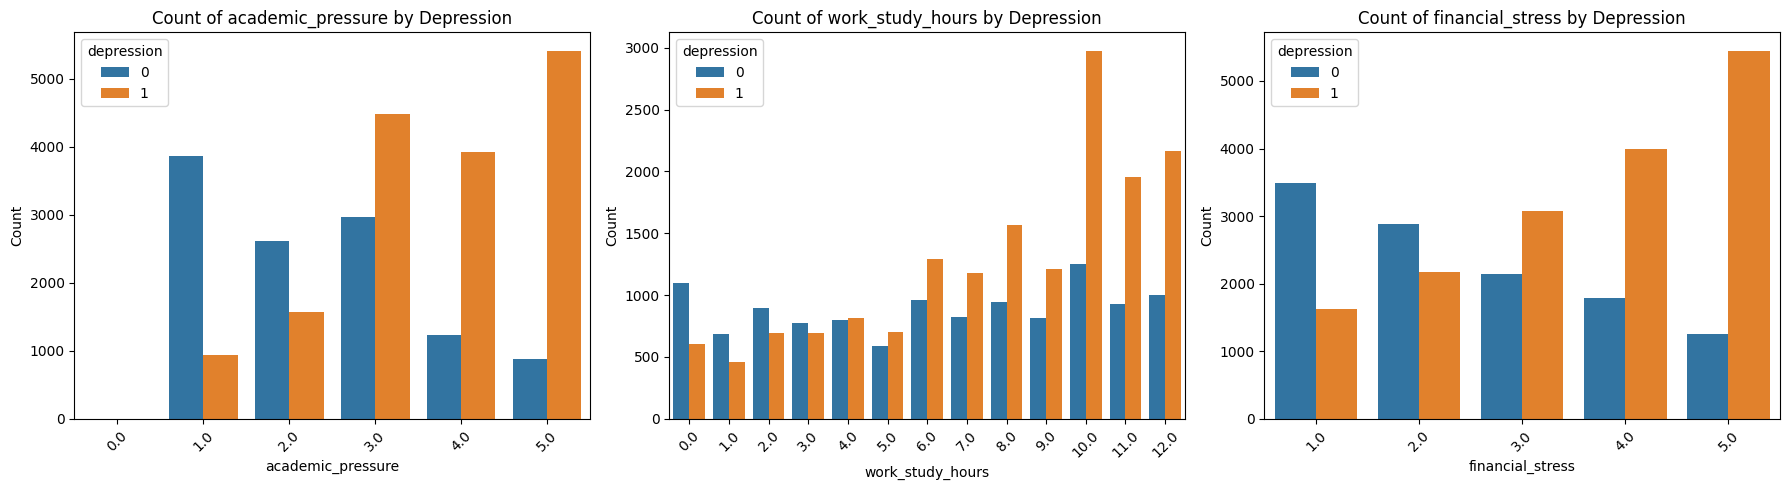

In [ ]:
features = ['academic_pressure', 'work_study_hours', 'financial_stress']

# Create a layout with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    sns.countplot(
        data=df,
        x=col,
        hue='depression',
        ax=axes[i]
    )

    axes[i].set_title(f'Count of {col} by Depression')
    axes[i].set_ylabel('Count')
    # Optional: Rotate x-labels if they overlap
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

-  Since the proportions are very different across categories, these features are informative

### (2) Categorical Features

In [ ]:
df[categorical_features].head()

,gender,city,profession,sleep_duration,dietary_habits,degree,suicidal_thoughts,family_history_mental_illness
0,Male,Visakhapatnam,Student,5-6 hours,Healthy,B.Pharm,Yes,No
1,Female,Bangalore,Student,5-6 hours,Moderate,BSc,No,Yes
2,Male,Srinagar,Student,Less than 5 hours,Healthy,BA,No,Yes
3,Female,Varanasi,Student,7-8 hours,Moderate,BCA,Yes,Yes
4,Female,Jaipur,Student,5-6 hours,Moderate,M.Tech,Yes,No


####- Feature vs Target

##### i) Mean of target

In [ ]:
for col in categorical_features:
    print(f"\n=== {col} vs depression (mean) ===")
    print(df.groupby(col)['depression'].mean().sort_values(ascending=False))


=== gender vs depression (mean) ===
gender
Male      0.586000
Female    0.584069
Name: depression, dtype: float64

=== city vs depression (mean) ===
city
3.0                   1.000000
Khaziabad             1.000000
Gaurav                1.000000
Bhavna                1.000000
Harsh                 1.000000
Mihir                 1.000000
Saanvi                1.000000
Vaanya                1.000000
Mira                  1.000000
M.Com                 1.000000
Nalini                1.000000
Ahmedabad             0.672287
Hyderabad             0.669156
Patna                 0.631213
Rajkot                0.625767
Bhopal                0.620579
Delhi                 0.608866
Kolkata               0.608818
Bangalore             0.608355
Indore                0.604977
Chennai               0.596154
Meerut                0.596107
Kalyan                0.593350
Thane                 0.590869
Faridabad             0.587852
Ludhiana              0.582507
Surat                 0.579777
Ghaziaba

**Mean of target = probability of depression(target = 1) per group**

We compare means across categories. If have bigger differences = stronger insight

Example:

**1. gender vs depression**
- Male      0.586287
- Female    0.584507

P.S. There are very small gap (58.62% vs 58.45%) between them, so this is **weak relationship**

***2. suicidal_thoughts vs depression***
- Yes → 0.790 (79% are depressed)
- No  → 0.232 (23% are depressed)

P.S. There are Huge gap (79% vs 23%) between them, so this is **strong relationship**


##### ii) Stacked Bar

A stacked bar chart is used to visually understand how the target is distributed inside each category

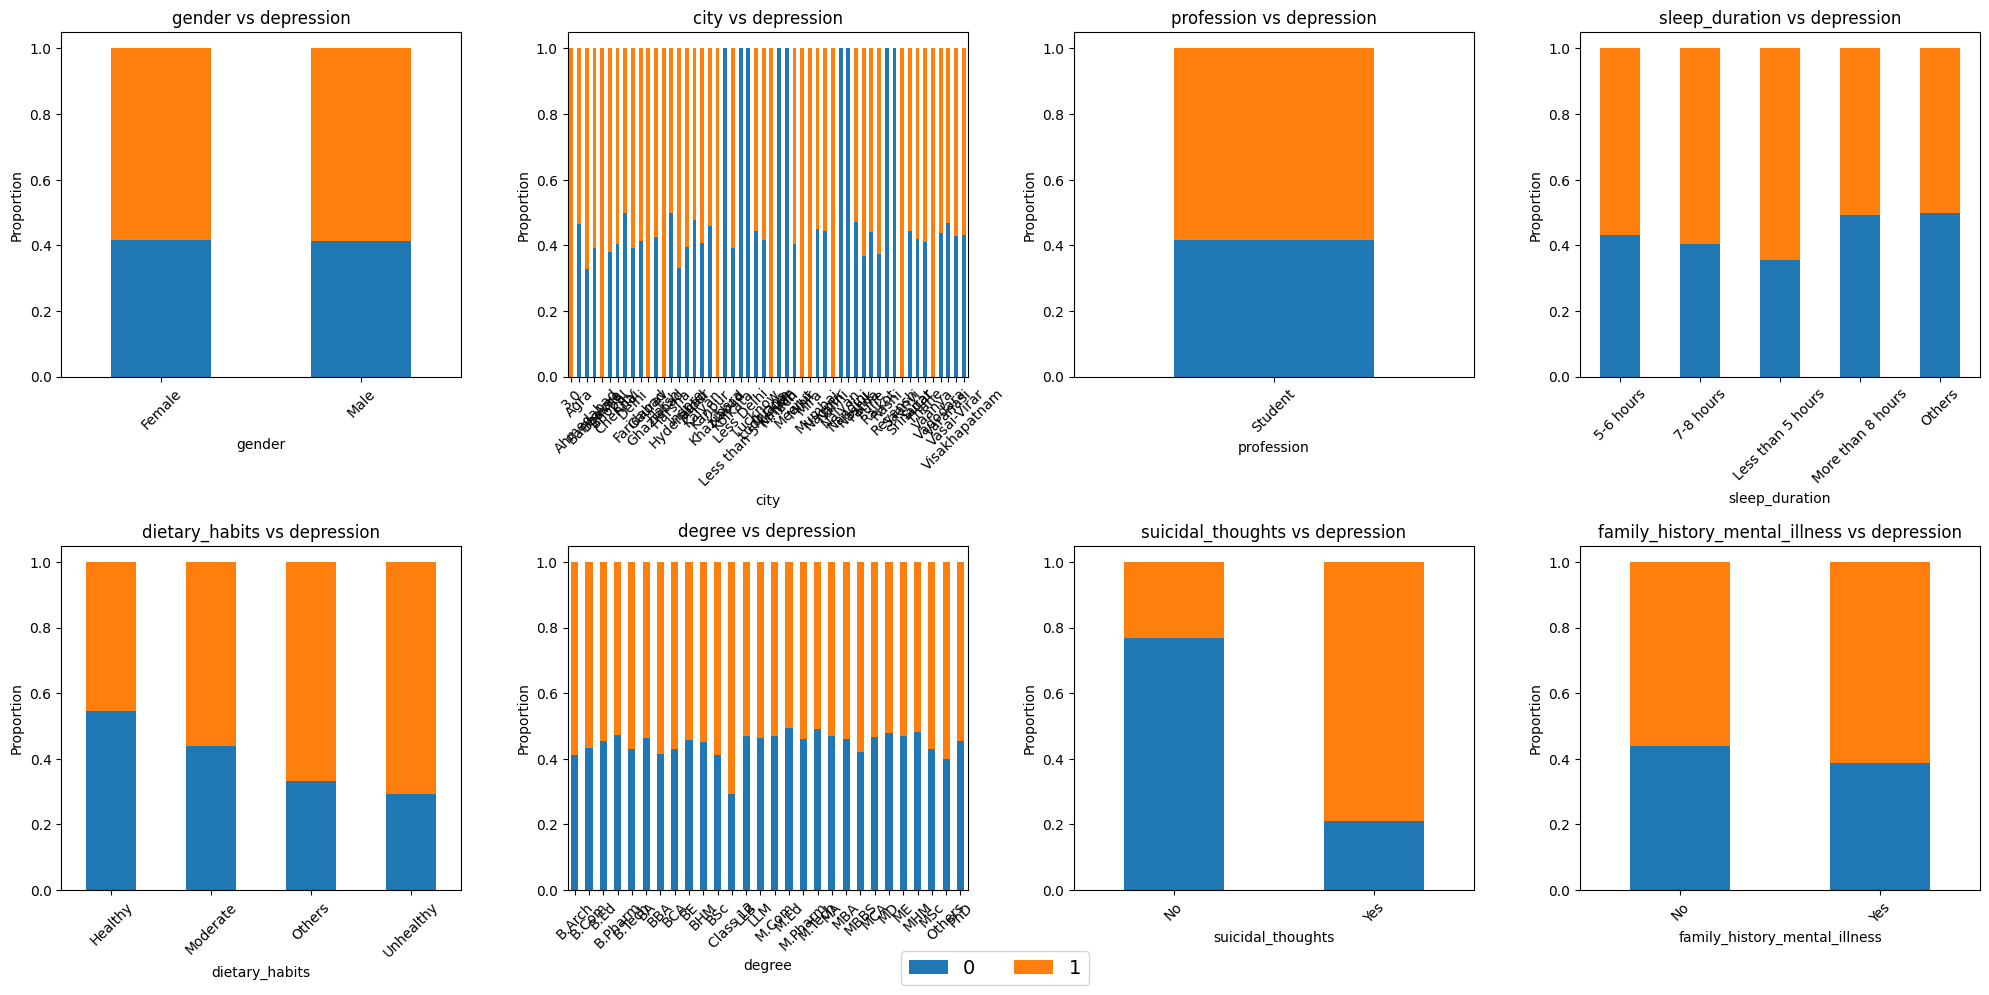

In [ ]:
cat_cols = categorical_features
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

axes = axes.flatten()  # make indexing easier

for i, col in enumerate(cat_cols):
    ax = axes[i]

    props = pd.crosstab(df[col], df['depression'], normalize='index')
    props.plot(kind='bar', stacked=True, ax=ax, legend=False)  # ❌ remove per-plot legend

    ax.set_title(f"{col} vs {target}")
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)

# remove empty subplots (if any)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

# ✅ create ONE legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2,fontsize=14)

plt.tight_layout()
plt.show()

Top 10 City

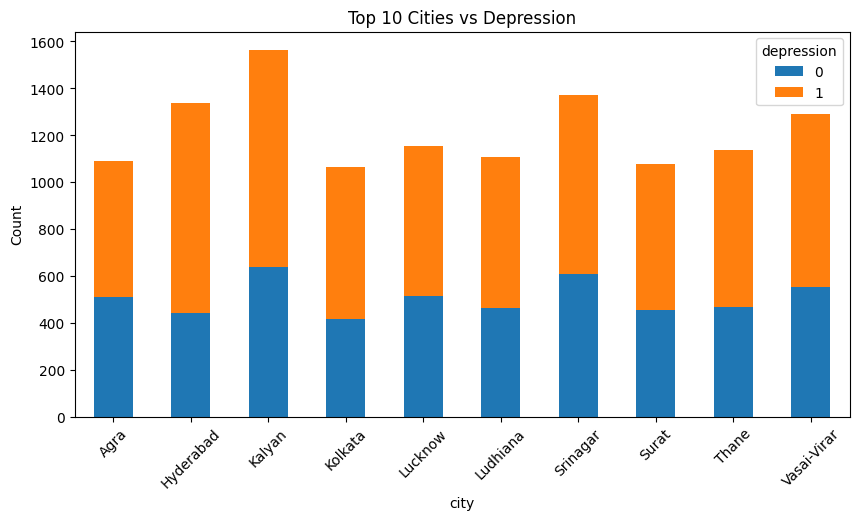

In [ ]:
top_cities = df['city'].value_counts().nlargest(10).index

city_top = df[df['city'].isin(top_cities)]

city_ct = pd.crosstab(city_top['city'], city_top['depression'])

city_ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Top 10 Cities vs Depression")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Top 10 Degree

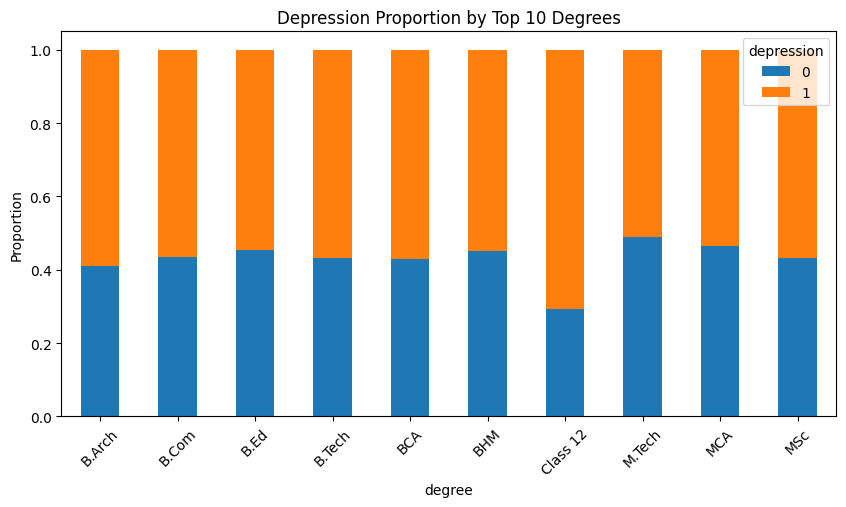

In [ ]:
top_degree = df['degree'].value_counts().nlargest(10).index

degree_top = df[df['degree'].isin(top_degree)]

degree_ct = pd.crosstab(
    degree_top['degree'],
    degree_top['depression'],
    normalize='index'
)

degree_ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Depression Proportion by Top 10 Degrees")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

 ##### iii) ChiSquare Test

In [ ]:
results = []

for col in categorical_features:
    table = pd.crosstab(df[col], df['depression'])
    chi2, p, dof, _ = chi2_contingency(table)

    results.append((col, p))

chi_df = pd.DataFrame(results, columns=['feature', 'p_value'])

# sort by significance
chi_df = chi_df.sort_values('p_value')

# add pass/fail column
chi_df['result'] = chi_df['p_value'].apply(
    lambda p: 'PASS (significant)' if p < 0.05 else 'FAIL (not significant)'
)

print(chi_df)

                         feature        p_value                  result
6              suicidal_thoughts   0.000000e+00      PASS (significant)
4                 dietary_habits  8.319821e-261      PASS (significant)
5                         degree   1.439818e-95      PASS (significant)
3                 sleep_duration   9.053487e-59      PASS (significant)
7  family_history_mental_illness   5.118661e-19      PASS (significant)
1                           city   1.749655e-17      PASS (significant)
0                         gender   7.544599e-01  FAIL (not significant)
2                     profession   1.000000e+00  FAIL (not significant)


In a Chi-square test, the p-value tells us whether the relationship between a categorical feature and the target is likely real or just happened by chance

**If p < 0.05,**
- It means the result is likely not random, so the feature is probably related to the target and can be useful.

 **If p ≥ 0.05**
- It means the result could be random, so the feature is probably not strongly related to the target.

##### iv) Cramer's V

Cramér’s V is a statistical measure that shows the strength of association between two categorical variables (from 0 = no relationship to 1 = perfect relationship).

In [ ]:
# Define a function for Cramer's V
def cramers_v(x, y):
    # create contingency table
    table = pd.crosstab(x, y)

    # chi-square test
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()

    # correction for bias (important for small tables)
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [ ]:
cat_cols = categorical_features

results = []

for col in cat_cols:
    v = cramers_v(df[col], df['depression'])
    results.append((col, v))

cramer_df = pd.DataFrame(results, columns=['feature', 'cramers_v'])
cramer_df = cramer_df.sort_values('cramers_v', ascending=False)

print(cramer_df)

                         feature  cramers_v
6              suicidal_thoughts   0.546336
4                 dietary_habits   0.207623
5                         degree   0.134881
3                 sleep_duration   0.099006
1                           city   0.069977
7  family_history_mental_illness   0.053033
0                         gender   0.000000
2                     profession        NaN


/tmp/ipykernel_5463/2984707258.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


The **`city_grouped`** and **`degree`** features contain user-entered categorical values with inconsistent formatting and possible spelling variations. Since the original values could not be reliably verified, only minimal preprocessing was applied to avoid introducing subjective assumptions or incorrect mappings.

Cramér’s V is similar to a correlation heatmap in that it shows the strength of relationships between variables, but it is specifically used for categorical features and categorical targets (e.g., 0/1), while correlation heatmaps are used for numerical variables.

- So we can notice that **`suicidal_thoughts`** have moderate relationship; **`gender`** almost no relationship with depression

- **`profession`** feature show **`NaN`** because this feature has only 1 unique value (constant column) which is student, so Cramér’s V cannot function properly because there is no variation to compare.

**Note:**

**Categorical Target** -> labels/groups (can be numbers or words format)

**Numerical Target** -> continuous value (House price → 250000, 300000)

# **C)DATA SPLITING**

The dataset is split into training and testing sets after completing  exploratory data analysis (EDA) to prevent **data leakage**, ensuring that information from the test set does not influence data preprocessing, feature engineering, or model training decisions.

In [ ]:
df

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
X = df.drop("depression", axis=1)
y = df["depression"]

In [ ]:
# Seperate to 80:20; Startify to ensure the distribution is still the same with original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Display the shape of the training and testing sets
print("Training set X shape:", X_train.shape)
print("Training set Y shape:", y_train.shape)
print("Testing set X shape:", X_test.shape)
print("Testing set Y shape:", y_test.shape)

Training set X shape: (22296, 16)
Training set Y shape: (22296,)
Testing set X shape: (5574, 16)
Testing set Y shape: (5574,)


# **D) DATA PREPROCESSING**

From EDA just now, we visualize and get that the numerical features **`work_pressure`**, **`job_satisfaction`**; categorical features **`gender`** and **`profession`** are useless for target variable


In [ ]:
X_train = X_train.drop(columns=["work_pressure","job_satisfaction","gender","profession"])
X_test = X_test.drop(columns=["work_pressure","job_satisfaction","gender","profession"])

## (1) Numerical Features

In [ ]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numerical_features]

,age,academic_pressure,cgpa,study_satisfaction,work_study_hours,financial_stress
10554,27.0,2.0,7.94,2.0,9.0,5.0
18537,19.0,4.0,8.62,5.0,10.0,4.0
5764,21.0,5.0,9.98,4.0,9.0,3.0
27634,31.0,4.0,8.04,5.0,11.0,2.0
5184,27.0,3.0,5.57,5.0,3.0,5.0
...,...,...,...,...,...,...
18223,20.0,3.0,8.03,4.0,12.0,4.0
18449,20.0,2.0,5.47,5.0,0.0,5.0
8317,22.0,1.0,5.88,5.0,7.0,2.0
16530,20.0,5.0,8.89,2.0,7.0,4.0


In [ ]:
X_train.describe()

,age,academic_pressure,cgpa,study_satisfaction,work_study_hours,financial_stress
count,22296.000000,22296.000000,22296.000000,22296.000000,22296.000000,22293.000000
mean,25.833558,3.139263,7.667410,2.936581,7.149309,3.134392
std,4.912371,1.379122,1.470342,1.360915,3.710443,1.437672
min,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,6.345000,2.000000,4.000000,2.000000
50%,26.000000,3.000000,7.790000,3.000000,8.000000,3.000000
75%,30.000000,4.000000,8.930000,4.000000,10.000000,4.000000
max,59.000000,5.000000,10.000000,5.000000,12.000000,5.000000


FROM EDA boxplot, we have info
- Have outlier  : **Age**,  **CGPA**
- No outlier : **Academic Pressure**, **Study Satisfaction**, **Study Hours**
- Missing values : **Financial Stress**

**Age:**
- Age ranges from 18 to 59.
- No outliers were removed because older ages may represent mature students, postgraduate students, or working adults pursuing further studies.

**CGPA ：**
- CGPA ranges from 0 to 10, which is valid under the Indian 10-point CGPA system.
- CGPA values of 0 were retained as they may represent first-semester students who had not received exam results during the survey period.

## (2) Categorical Features

In [ ]:
categorical_features = X_train.select_dtypes(include=['object']).columns
X_train[categorical_features]

,city,sleep_duration,dietary_habits,degree,suicidal_thoughts,family_history_mental_illness
10554,Indore,Less than 5 hours,Unhealthy,MBA,Yes,No
18537,Chennai,7-8 hours,Unhealthy,Class 12,Yes,No
5764,Jaipur,More than 8 hours,Moderate,B.Com,Yes,No
27634,Ahmedabad,Less than 5 hours,Moderate,Class 12,Yes,Yes
5184,Patna,More than 8 hours,Unhealthy,BCA,Yes,No
...,...,...,...,...,...,...
18223,Rajkot,Less than 5 hours,Unhealthy,Class 12,Yes,Yes
18449,Ludhiana,More than 8 hours,Unhealthy,Class 12,Yes,Yes
8317,Ludhiana,7-8 hours,Healthy,MCA,No,No
16530,Visakhapatnam,More than 8 hours,Unhealthy,Class 12,Yes,Yes


FROM EDA, we have info
- Too many values（high-cardinality） : **city**,  **degree**
- Ordinal Data : **sleep_duration**, **dietary_habits**
- Yes/No : **suicidal_thoughts**， **family_history_mental_illness**




### City

**City**:

- A frequency threshold was applied to the city column to retain only cities with sufficient occurrences in the dataset.
- Cities with occurrences below the threshold were grouped into an "Others" category to reduce noise and improve model performance.

In [ ]:
city_counts = X_train["city"].value_counts()
print(city_counts)

city
Kalyan                1257
Srinagar              1088
Hyderabad             1075
Vasai-Virar           1011
Lucknow                922
Thane                  904
Agra                   876
Surat                  872
Kolkata                870
Ludhiana               865
Patna                  821
Jaipur                 813
Visakhapatnam          782
Pune                   758
Ahmedabad              754
Bhopal                 752
Chennai                707
Rajkot                 665
Meerut                 664
Bangalore              619
Ghaziabad              597
Delhi                  587
Mumbai                 569
Vadodara               558
Nagpur                 527
Varanasi               527
Indore                 508
Kanpur                 480
Nashik                 460
Faridabad              390
Saanvi                   2
Reyansh                  1
Nalini                   1
Mira                     1
3.0                      1
Less than 5 Kalyan       1
M.Com                  

In [ ]:
threshold_city = 350
top_cities = city_counts[city_counts >=  threshold_city].index

X_train["city"] = X_train["city"].apply(
    lambda x: x if x in top_cities else "Others"
)
X_test["city"] = X_test["city"].apply(
    lambda x: x if x in top_cities else "Others"
)

In [ ]:
print("\nShape:", X_train["city"].value_counts().shape)
print(X_train["city"].value_counts())


Shape: (31,)
city
Kalyan           1257
Srinagar         1088
Hyderabad        1075
Vasai-Virar      1011
Lucknow           922
Thane             904
Agra              876
Surat             872
Kolkata           870
Ludhiana          865
Patna             821
Jaipur            813
Visakhapatnam     782
Pune              758
Ahmedabad         754
Bhopal            752
Chennai           707
Rajkot            665
Meerut            664
Bangalore         619
Ghaziabad         597
Delhi             587
Mumbai            569
Vadodara          558
Nagpur            527
Varanasi          527
Indore            508
Kanpur            480
Nashik            460
Faridabad         390
Others             18
Name: count, dtype: int64


### Degree

**Degree**
- The degree feature contained multiple abbreviated education qualifications.
- It was assumed that degree values starting with `"B"` represent **Bachelor’s** degrees, `"M"` represent **Master’s** degrees, and `"PhD"` represent **Doctorate** qualifications; therefore, the values were grouped into broader education categories for consistency and easier analysis.

In [ ]:
degree_counts = X_train["degree"].value_counts()
print(degree_counts)

degree
Class 12    4836
B.Ed        1502
B.Com       1210
B.Arch      1170
BCA         1148
MSc          956
B.Tech       926
MCA          841
M.Tech       815
BHM          727
BSc          726
M.Ed         653
B.Pharm      642
M.Com        581
BBA          570
MBBS         559
LLB          521
BE           481
MD           475
M.Pharm      473
BA           465
MA           455
MBA          449
PhD          412
LLM          386
MHM          145
ME           144
Others        28
Name: count, dtype: int64


In [ ]:
degree_map = {
    # Foundation
    "Class 12": "Pre-University",

    # Undergraduate
    "B.Ed": "Bachelor", # Education
    "B.Com": "Bachelor", # Commerce
    "B.Arch": "Bachelor", # Architecture
    "BCA": "Bachelor", # Computer Applications
    "B.Tech": "Bachelor", # Technology
    "BHM": "Bachelor", # Hospitality Management
    "BSc": "Bachelor", # Science
    "B.Pharm": "Bachelor", # Pharmacy
    "BBA": "Bachelor", # Business Administration
    "BA": "Bachelor", # Arts
    "BE": "Bachelor", # Engineering
    "LLB": "Bachelor", # Laws
    "MBBS": "Bachelor", # Bachelor of Medicine, Bachelor of Surgery

     # Postgraduate
    "MSc": "Master",  # Science
    "MCA": "Master", # Computer Applications
    "M.Tech": "Master", # Technology
    "M.Ed": "Master", # Education
    "M.Com": "Master", # Commerce
    "MD": "Master", # Doctor of Medicine (In india as Postgraduate)
    "M.Pharm": "Master", # Pharmacy
    "MA": "Master", # Arts
    "MBA": "Master", # Business Administration
    "LLM": "Master", # Laws
    "MHM": "Master", # Hospitality Management
    "ME": "Master", # Engineering

    # PhD
    "PhD": "Doctorate",

    "Others": "Others"
}

X_train["degree"] = X_train["degree"].map(degree_map)
X_test["degree"] = X_test["degree"].map(degree_map)

In [ ]:
print("\nShape:",X_train["degree"].value_counts().shape)
print(X_train["degree"].value_counts())



Shape: (5,)
degree
Bachelor          10647
Master             6373
Pre-University     4836
Doctorate           412
Others               28
Name: count, dtype: int64


### Sleep Duration and Dietary Habits

- The `Sleep Duration` and `Dietary Habits` features were treated as ordinal variables because their categories follow a meaningful order.
- The **"Others"** category did not represent a valid ordinal level and was therefore converted to NaN; during pipeline preprocessing, missing values were imputed using the most frequent category.

In [ ]:
print(X_train["sleep_duration"].value_counts())
print("\n")
print(X_train["dietary_habits"].value_counts())

sleep_duration
Less than 5 hours    6668
7-8 hours            5865
5-6 hours            4955
More than 8 hours    4796
Others                 12
Name: count, dtype: int64


dietary_habits
Unhealthy    8283
Moderate     7915
Healthy      6090
Others          8
Name: count, dtype: int64


In [ ]:
ordinal_cols = ["sleep_duration", "dietary_habits"]

for col in ordinal_cols:
    X_train[col] = X_train[col].replace("Others", np.nan)
    X_test[col] = X_test[col].replace("Others", np.nan)

In [ ]:
print("Missing values in X_train for ordinal_cols:")
print(X_train[ordinal_cols].isnull().sum())

Missing values in X_train for ordinal_cols:
sleep_duration    12
dietary_habits     8
dtype: int64


In [ ]:
X_train["sleep_duration"].value_counts(dropna=False)

,count
sleep_duration,
Less than 5 hours,6668
7-8 hours,5865
5-6 hours,4955
More than 8 hours,4796
NaN,12


## Pipeline

- After completing data preprocessing, a machine learning pipeline was constructed to automate the transformation process and ensure consistent handling of the dataset.
- The pipeline included missing value imputation, categorical encoding, ordinal encoding, scaling of numerical features, and model training within a single workflow.

In [ ]:
num_cols = ["age","academic_pressure","cgpa","study_satisfaction","work_study_hours","financial_stress"]
cat_cols = ["city", "degree"]
ordinal_cols = ["sleep_duration", "dietary_habits"]
binary_cols = ["suicidal_thoughts", "family_history_mental_illness"]

sleep_order =["Less than 5 hours","5-6 hours", "7-8 hours","More than 8 hours"]
diet_order=["Unhealthy","Moderate","Healthy"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[sleep_order, diet_order]))
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder())
])

In [ ]:
# Combine Together
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("bin", binary_pipeline, binary_cols)
])

# **E) MODELING**

For depression datasets, recall and F1-score are usually very important because:
missing depressed students can be costly

Recall is prioritized because failing to identify depressed students could have serious consequences.

❌ Wrong approach:
- Tune Logistic Regression → then Random Forest → then XGBoost (deep tuning all)

✅ Correct approach:
- Try all models → pick best → then tune that model

### Function Evaluation

In [ ]:
from sklearn.model_selection import cross_validate

def evaluate_model(model, X_train, y_train, model_name):

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_train_score=True
    )

    results = {
        "Model": model_name,

        "Train Accuracy": scores['train_accuracy'].mean()*100,
        "Validation Accuracy": scores['test_accuracy'].mean()*100,

        "Train Precision": scores['train_precision'].mean()*100,
        "Validation Precision": scores['test_precision'].mean()*100,

        "Train Recall": scores['train_recall'].mean()*100,
        "Validation Recall": scores['test_recall'].mean()*100,

        "Train F1": scores['train_f1'].mean()*100,
        "Validation F1": scores['test_f1'].mean()*100,

        "Training Time(s)": scores['fit_time'].mean(),
        "Validation Time(s)": scores['score_time'].mean()
    }

    return results

## **Base Model (Logistic Regression)**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

lr_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


### **i) Train model**

In [ ]:
lr_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE...
                                                                                               'than '
                                                                                               '5 '
                                                                                               'hours',
                                                                                               '5-6 '
                                                                                               'hours',
                                                                                               '7-8 '
                                                                                               'hours',
                                                                                               'More '
                                                                                               'than '
                                                                                               '8 '
                                                                                               'hours'],
                                                                                              ['Unhealthy',
                                                                                               'Moderate',
                                                                                               'Healthy']]))]),
                                                  ['sleep_duration',
                                                   'dietary_habits']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['suicidal_thoughts',
                                                   'family_history_mental_illness'])])),
                ('model', LogisticRegression(random_state=42))])

### **ii) Validate Data**

In [ ]:
lr_results = evaluate_model(lr_clf, X_train, y_train, "Logistic Regression")

## **Random Forest**

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE...
                                                                                               'hours',
                                                                                               '5-6 '
                                                                                               'hours',
                                                                                               '7-8 '
                                                                                               'hours',
                                                                                               'More '
                                                                                               'than '
                                                                                               '8 '
                                                                                               'hours'],
                                                                                              ['Unhealthy',
                                                                                               'Moderate',
                                                                                               'Healthy']]))]),
                                                  ['sleep_duration',
                                                   'dietary_habits']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['suicidal_thoughts',
                                                   'family_history_mental_illness'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
rf_results = evaluate_model(
    rf_clf,
    X_train,
    y_train,
    "Random Forest"
)

## **XG Boost**



In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# XGBoost model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Pipeline
xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Train
xgb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
xgb_results = evaluate_model(
    xgb_clf,
    X_train,
    y_train,
    "XGBoost"
)

## **Comparison Model Algorithms**

In [ ]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df

,Model,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1,Training Time(s),Validation Time(s)
0,Logistic Regression,84.921063,84.791011,85.869450,85.721348,88.850989,88.801144,87.334745,87.232353,0.145916,0.046175
1,Random Forest,100.000000,84.059939,100.000000,85.105845,100.000000,88.195618,100.000000,86.620072,15.722509,0.144268
2,XGBoost,92.547993,83.876050,92.683655,85.400517,94.743601,87.383117,93.702259,86.378444,0.370607,0.051550


**1. Logistic Regression**
- This model performs the best overall on validation data.
- Train and validation results are very close → shows good generalization (**no overfitting**).
- It is also the fastest and simplest model to train.

**2. Random Forest**
- Perfect performance on training data (100%) but lower performance on validation data.
- This shows **overfitting** (model memorizes training data).
- Training time is also the slowest among all models (take 20 seconds for training data.）

**3. XG Boost**
- Good training performance, but slightly lower validation results than Logistic Regression.
- Validation F1-score (86.38%) is also lower.


**Conclusion:**

Based on this table, I decided to fine tune `Logistic Regression` and `XGBoost`.

- `Logistic Regression:` This model performs best on validation metrics with fast training and good generalization, so it is suitable for fine tuning.
- `XGBoost:` This model has strong performance and fast training time, so it is also worth fine tuning to try to improve results.
- `Random Forest:` This model is excluded from fine tuning because it has long training time, shows overfitting, and does not improve validation performance.

# **F) FINE TUNING MODEL**

## **Grid Search**

### i) Linear Regression

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"]
    }
]

grid_search_lr = GridSearchCV(
    lr_clf,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train, y_train)

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV score(recall):", grid_search_lr.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV score(recall): 0.8942197726995709


In [ ]:
best_lr = grid_search_lr.best_estimator_

### ii) XG Boost

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    xgb_clf,
    param_grid,
    cv=5,
    scoring="recall",   # focus on detecting depressed students
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print("Best parameters:", grid_search_xgb.best_params_)
print("Best CV score(recall):", grid_search_xgb.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV score(recall): 0.914303361925783


In [ ]:
best_xgb = grid_search_xgb.best_estimator_

 XGBoost achieved a higher cross-validation score during hyperparameter tuning, evaluation on the test dataset was still necessary to confirm that the model could generalize well to unseen data and maintain strong predictive performance.

## **Learning Curves**

A learning curve is a graph that shows how a model’s performance changes as the training data size increases.

### i) Linear Regression

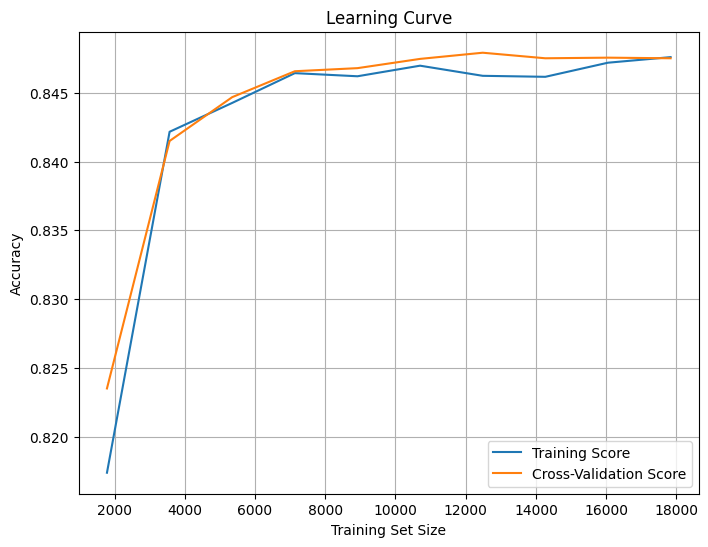

In [ ]:
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator= best_lr,
    X=X_train,
    y=y_train,
    cv=5,                  # 5-fold cross validation
    scoring='accuracy',    # change metric if needed
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, val_mean, label='Cross-Validation Score')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.grid(True)

plt.show()

In this learning curve, the training accuracy and cross-validation accuracy are very close to each other, which means the model is **not overfitting** and can generalize well to new data.

### ii) XG Boost

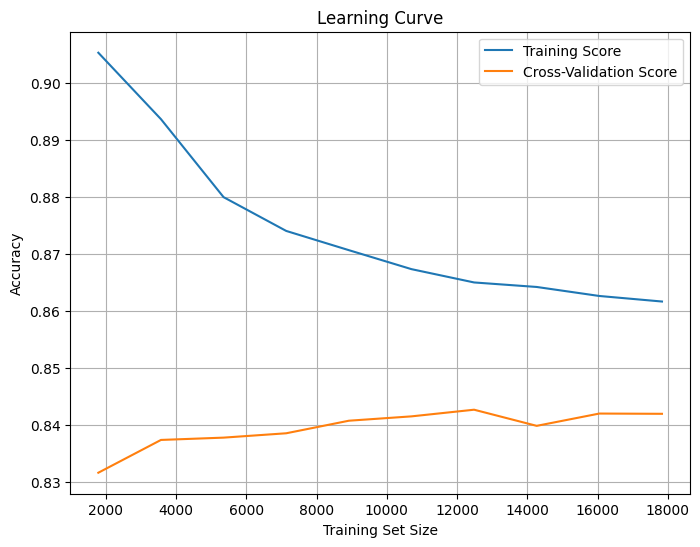

In [ ]:
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator= best_xgb,
    X=X_train,
    y=y_train,
    cv=5,                  # 5-fold cross validation
    scoring='accuracy',    # change metric if needed
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, val_mean, label='Cross-Validation Score')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.grid(True)

plt.show()

The learning curve indicates mild overfitting, as the training accuracy remains consistently higher than validation accuracy, but the stable validation trend suggests good generalization performance.

# **G) Evaluation**

## **Test Data**

 i) Linear Regression

In [ ]:
best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr .predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.4f}")

Accuracy: 0.8452
Precision: 0.8527
Recall: 0.8890
F1 Score: 0.8705


ii) XG Boost

In [ ]:
best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb .predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")

Accuracy: 0.8405
Precision: 0.8311
Recall: 0.9129
F1 Score: 0.8701


## **Compare Two Models**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8452,0.8527,0.8890,0.8705
1,XGBoost,0.8405,0.8311,0.9129,0.8701


**`XGBoost`** was selected as the **final model** because it achieved the highest recall score, allowing the model to detect more students who may have depression, which aligns with the objective of minimizing missed positive cases.

## **Confusion Matrix / Classification Report**

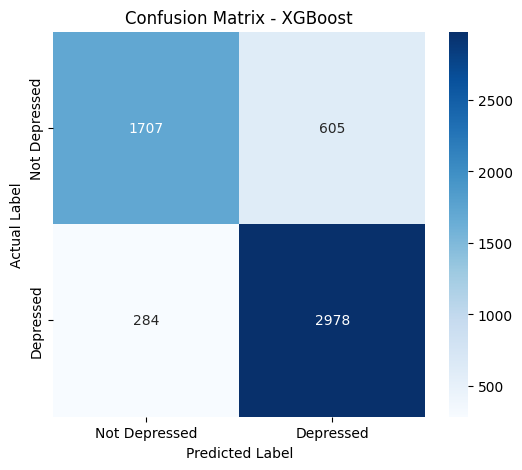



Classification Report
              precision    recall  f1-score   support

           0       0.86      0.74      0.79      2312
           1       0.83      0.91      0.87      3262

    accuracy                           0.84      5574
   macro avg       0.84      0.83      0.83      5574
weighted avg       0.84      0.84      0.84      5574



In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Depressed", "Depressed"],
            yticklabels=["Not Depressed", "Depressed"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

print("\n")
print("Classification Report")
print(classification_report(y_test, y_pred_xgb))


## **ROC Curve**

The ROC curve evaluates how well the model separates the two classes across all
possible classification thresholds.

The closer the curve is to the top-left corner, the better the classifier:
- High True Positive Rate
- Low False Positive Rate

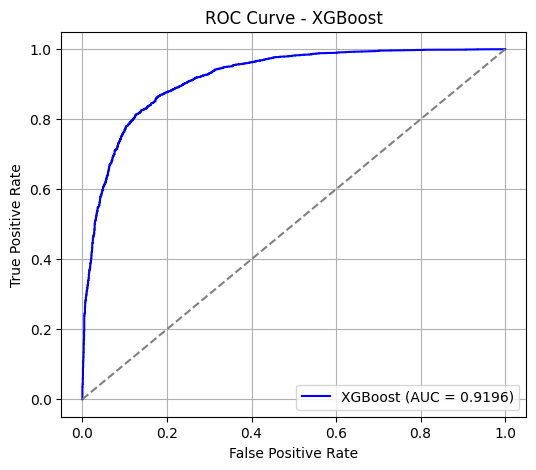

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probability scores (important for ROC)
y_proba_xgb = grid_search_xgb.best_estimator_.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()

**Area Under the Curve (AUC)**
- `AUC = 0.9196` indicating strong ability to distinguish between positive and negative classes
- It means that there is about a **91.96%** chance that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance.

## **Precision–Recall Curve**

The Precision–Recall curve evaluates the tradeoff between Precision and Recall

The closer the curve is to Top-Right Corner, the better model is:
- This represents a perfect model with (100%) precision and (100%) recall. The closer your curve bows toward this corner.

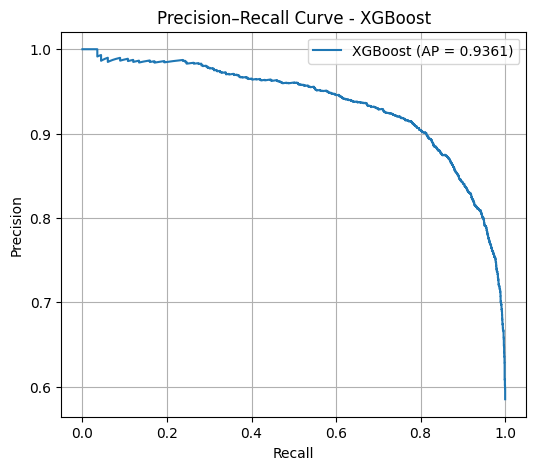

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)
ap_score = average_precision_score(y_test, y_proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"XGBoost (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()

The model maintains **high precision** while **increasing recall**, so it correctly identifies positive cases without generating many false positives.

The Precision–Recall curve shows that the XGBoost model maintains high precision across different recall levels, achieving an excellent Average Precision (AP) score of 0.9361.


## **Precision-Recall Threshold Curve**

The Precision–Recall Threshold curve shows how precision and recall change at different classification thresholds, helping determine the optimal threshold for balancing false positives and false negatives.

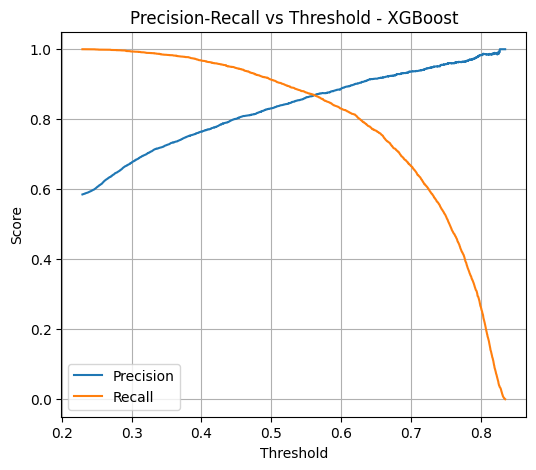

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold - XGBoost")
plt.legend()
plt.grid()
plt.show()

This graph is used to show the trade-off between precision and recall when the threshold changes.

- When the **threshold is higher**, the **model becomes stricter**, causing `precision` to **increase** but `recall` to **decrease** because more positive cases are missed.
- When the **threshold is lower**, `recall` **increases** because more positive cases are detected, but `precision` may **decrease** due to more false positives.

This graph helps determine the most suitable threshold based on the problem requirements.

#### Check threshold if we want recall = 0.95

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Find threshold where recall is closest to 0.95
target_recall = 0.95

idx = np.argmin(np.abs(recall[:-1] - target_recall))

best_threshold = thresholds[idx]

# Convert probabilities to predictions at the best_threshold
y_pred_at_threshold = (y_proba_xgb >= best_threshold).astype(int)

# Calculate metrics at this threshold
accuracy_at_threshold = accuracy_score(y_test, y_pred_at_threshold)
precision_at_threshold = precision_score(y_test, y_pred_at_threshold)
recall_at_threshold = recall_score(y_test, y_pred_at_threshold)
f1_score_at_threshold = f1_score(y_test, y_pred_at_threshold)

print("Threshold:", best_threshold)
print()
print("Performance Metrics")
print("Accuracy  :", accuracy_at_threshold)
print("Precision :", precision_at_threshold)
print("Recall    :", recall_at_threshold)
print("F1-score  :", f1_score_at_threshold)

Threshold: 0.44110572

Performance Metrics
Accuracy  : 0.8272335844994618
Precision : 0.794819184406258
Recall    : 0.9500306560392398
F1-score  : 0.8655215751989945


Since the objective is to detect student depression, the classification threshold was adjusted to **enhance recall** from `91.29% to 95.00%`, **reducing the likelihood of missing depressed students**.As a tradeoff, the accuracy, precision, and F1-score decreased slightly.

However, this adjustment is acceptable because identifying more students with potential depression is prioritized over the risk of not detecting students who may actually have depression.

# **H) Save Model**

In [ ]:
joblib.dump(best_xgb, "/content/drive/MyDrive/model.joblib")

['/content/drive/MyDrive/model.joblib']

In [ ]:
print(sklearn.__version__)

1.6.1


In [ ]:
!python --version

Python 3.12.13


In [ ]:
df_test = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
display(df_test.head())

,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression
0,28.0,Varanasi,2.0,8.14,3.0,7-8 hours,Healthy,Bachelor,No,0.0,1.0,No,0
1,21.0,Pune,5.0,9.89,5.0,5-6 hours,Healthy,Bachelor,Yes,12.0,5.0,No,1
2,23.0,Rajkot,4.0,7.51,1.0,7-8 hours,Healthy,Bachelor,Yes,7.0,2.0,Yes,1
3,26.0,Kalyan,3.0,9.13,4.0,More than 8 hours,Moderate,Bachelor,Yes,10.0,3.0,Yes,0
4,30.0,Kolkata,3.0,7.10,5.0,7-8 hours,Moderate,Master,Yes,10.0,1.0,Yes,0
